해당 부분은 순수 공부의 목적으로 제작한 것이므로 참고만 하길 바람.

1. VRP
VRP(Vehicle Routing Problem)는 물류 및 운송 분야에서 활용되는 최적화 문제로,
주어진 조건 하에서 전체 운행 비용(거리, 시간 등)을 최소화하는 차량 경로를 도출하는 방법이다.

사용자는 비용의 기준과 다양한 제약 조건을 설정할 수 있으며,
이를 통해 필요한 차량 수와 효율적인 운행 경로를 분석할 수 있다.

일반적인 물류 시스템에서는 차량이 특정 거점(depot)에서 출발하여
다시 해당 위치로 복귀하는 구조를 갖는 경우가 많다.
OR-Tools의 기본 설정 역시 이러한 구조를 반영하여 depot을 동일하게 설정한다.

다만, 출발지와 도착지를 다르게 설정하거나,
여러 허브를 사용하는 경우에는 dummy 노드 또는 다중 시작/종료 지점을 활용하여
보다 유연한 모델링이 가능하다.


1. GLOP를 통한 선형화와 최적의 지점좌표를 발견

In [1]:
from ortools.init.python import init
from ortools.linear_solver import pywraplp # pywraplp: C++ 솔버를 Python화 시킨 것


# 1. 벡엔드 설정, 문제 solver를 선정

solver = pywraplp.Solver.CreateSolver("GLOP")

#GLOP(Google Linearlization Optimization Programming) : 선형화 작업을 진행하여 기존의 작업을 최대한 단순화 시켜, 보다 간편화 하는 작업.
#내가 하는 CBS 작업에는 큰 역할은 부여하지 않지만, 보조 역할 수준은 가능.

if not solver:
    print("GLOP 못함 ㅇㅇ")

x = solver.NumVar(0, solver.infinity(), "x")
y = solver.NumVar(0, solver.infinity(), "y")

print("Number of variables =", solver.NumVariables())

# 범위에 지정된 함수들
# Constraint 0: x + 2y <= 14.
solver.Add(x + 2 * y <= 14.0)

# Constraint 1: 3x - y >= 0.
solver.Add(3 * x - y >= 0.0)

# Constraint 2: x - y <= 2.
solver.Add(x - y <= 2.0)

print("Number of constraints =", solver.NumConstraints())

# Objective function: 3x + 4y. -> 얘가 대상 함수
solver.Maximize(3 * x + 4 * y)

print(f"Solving with {solver.SolverVersion()}")
status = solver.Solve()

if status == pywraplp.Solver.OPTIMAL:
    print("Solution:")
    print(f"Objective value = {solver.Objective().Value():0.1f}")
    print(f"x = {x.solution_value():0.1f}")
    print(f"y = {y.solution_value():0.1f}")
else:
    print("The problem does not have an optimal solution.")



Number of variables = 2
Number of constraints = 3
Solving with Glop solver v9.15.6755
Solution:
Objective value = 34.0
x = 6.0
y = 4.0


2. Routing: VRP 전용

-사용하는 라이브러리
from ortools.constraint_solver import pywrapcp, routing_enums_pb2

Objective: 177500
Route for vehicle 0:
 0 ->  9 ->  10 ->  2 ->  6 ->  5 -> 0
Distance of the route: 1712m

Route for vehicle 1:
 0 ->  16 ->  14 ->  8 -> 0
Distance of the route: 1484m

Route for vehicle 2:
 0 ->  7 ->  1 ->  4 ->  3 -> 0
Distance of the route: 1552m

Route for vehicle 3:
 0 ->  13 ->  15 ->  11 ->  12 -> 0
Distance of the route: 1552m

Maximum of the route distances: 1712m


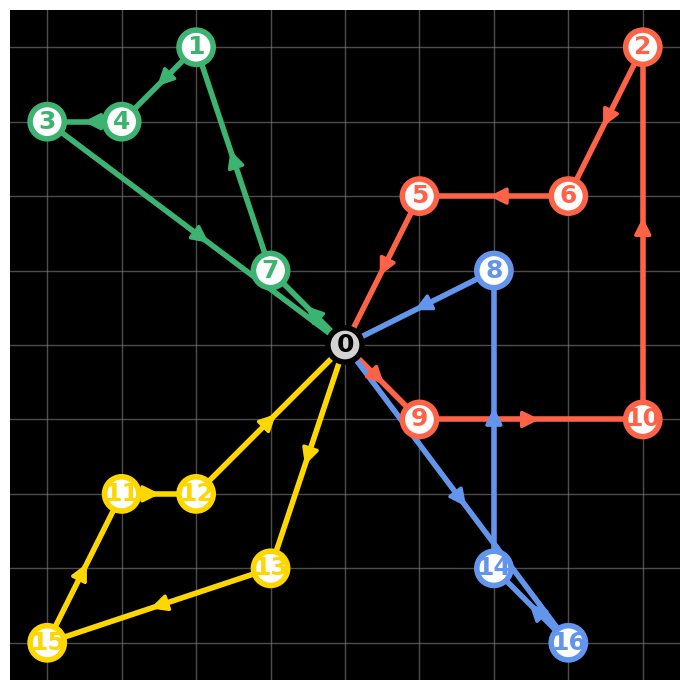

In [2]:
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import time


def create_data_model():
    """Stores the data for the problem."""
    data = {} # 딕셔너리
    data["distance_matrix"] = [
        # fmt: off
      [0, 548, 776, 696, 582, 274, 502, 194, 308, 194, 536, 502, 388, 354, 468, 776, 662],
      [548, 0, 684, 308, 194, 502, 730, 354, 696, 742, 1084, 594, 480, 674, 1016, 868, 1210],
      [776, 684, 0, 992, 878, 502, 274, 810, 468, 742, 400, 1278, 1164, 1130, 788, 1552, 754],
      [696, 308, 992, 0, 114, 650, 878, 502, 844, 890, 1232, 514, 628, 822, 1164, 560, 1358],
      [582, 194, 878, 114, 0, 536, 764, 388, 730, 776, 1118, 400, 514, 708, 1050, 674, 1244],
      [274, 502, 502, 650, 536, 0, 228, 308, 194, 240, 582, 776, 662, 628, 514, 1050, 708],
      [502, 730, 274, 878, 764, 228, 0, 536, 194, 468, 354, 1004, 890, 856, 514, 1278, 480],
      [194, 354, 810, 502, 388, 308, 536, 0, 342, 388, 730, 468, 354, 320, 662, 742, 856],
      [308, 696, 468, 844, 730, 194, 194, 342, 0, 274, 388, 810, 696, 662, 320, 1084, 514],
      [194, 742, 742, 890, 776, 240, 468, 388, 274, 0, 342, 536, 422, 388, 274, 810, 468],
      [536, 1084, 400, 1232, 1118, 582, 354, 730, 388, 342, 0, 878, 764, 730, 388, 1152, 354],
      [502, 594, 1278, 514, 400, 776, 1004, 468, 810, 536, 878, 0, 114, 308, 650, 274, 844],
      [388, 480, 1164, 628, 514, 662, 890, 354, 696, 422, 764, 114, 0, 194, 536, 388, 730],
      [354, 674, 1130, 822, 708, 628, 856, 320, 662, 388, 730, 308, 194, 0, 342, 422, 536],
      [468, 1016, 788, 1164, 1050, 514, 514, 662, 320, 274, 388, 650, 536, 342, 0, 764, 194],
      [776, 868, 1552, 560, 674, 1050, 1278, 742, 1084, 810, 1152, 274, 388, 422, 764, 0, 798],
      [662, 1210, 754, 1358, 1244, 708, 480, 856, 514, 468, 354, 844, 730, 536, 194, 798, 0],
        # fmt: on 
        # fmt는 formatting을 의미하는 것으로, 특정 프로그램이 해당 문구를 읽으면 자동적으로 본인들이 쉽게 가독성을 변경함
        # 대표적으로 Black, autoppep8 등의 프로그램들이 있다. 
        # 따라서, 해당 내용은 이 부분은 자동 정렬하지 말라는 뜻이다.
    ]
    data["num_vehicles"] = 4 # 차량 수
    data["depot"] = 0 # 모든 차량의 시작점과 끝점. node의 시작점과도 같은 의미
    return data

"""print_solution의 경우에는 def main()에서 생성하고 출력한 경로를 베이스를 기준으로 거리 계산을 진행한ㄷ,"""
def print_solution(data, manager, routing, solution):
    """Prints solution on console."""
    print(f"Objective: {solution.ObjectiveValue()}") #.ObjectiveValue(): 최적화된 결과값을 추출
    max_route_distance = 0
    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)
        plan_output = f"Route for vehicle {vehicle_id}:\n"
        route_distance = 0
        while not routing.IsEnd(index): # 해당 index가 끝나지 않는 경우, 아래의 과정을 계속 진행하라
            plan_output += f" {manager.IndexToNode(index)} -> " #IndexToNode() Index를 실제 Node로 변형함
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle( # () 내의 index를 전부 고려해 거리 cost를 계산
                previous_index, index, vehicle_id 
            )
        plan_output += f"{manager.IndexToNode(index)}\n"
        plan_output += f"Distance of the route: {route_distance}m\n"
        print(plan_output)
        max_route_distance = max(route_distance, max_route_distance) # 전체(4대의 차량)에서 가장 긴 경로 출력
    print(f"Maximum of the route distances: {max_route_distance}m")

    # 이때, 변수나 입력 값이 아예 없는데 어떻게 계산을 할 수 있는지 의아할 것이다. 해당 코딩들은 def 정의를 통해서 solution, callback(입력)에 대한 정의를 전부 따로따로 했기에 궁극적으로는 def의 내용을 모두 reading 하고 def solution이 작동.


def extract_routes(data, manager, routing, solution):
    """차량별 route를 [0, ..., 0] 형태로 추출"""
    routes = []

    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)
        route = [manager.IndexToNode(index)]

        while not routing.IsEnd(index):
            index = solution.Value(routing.NextVar(index))
            route.append(manager.IndexToNode(index))

        routes.append(route)

    return routes

def plot_routes(data, manager, routing, solution):
    """기존 OR-Tools 결과를 그림으로 시각화"""
    routes = extract_routes(data, manager, routing, solution)

    # -----------------------------
    # 노드 좌표 직접 지정
    # 이미지처럼 보이게 임의 배치
    # 해당 구간은 단순 시각화용
    # -----------------------------
    pos = {
        0: (0, 0),

        1: (-2, 4),
        2: (4, 4),
        3: (-4, 3),
        4: (-3, 3),
        5: (1, 2),
        6: (3, 2),
        7: (-1, 1),
        8: (2, 1),
        9: (1, -1),
        10: (4, -1),
        11: (-3, -2),
        12: (-2, -2),
        13: (-1, -3),
        14: (2, -3),
        15: (-4, -4),
        16: (3, -4),
    }

    # 차량별 색상
    colors = ["tomato", "cornflowerblue", "mediumseagreen", "gold"]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.set_facecolor("black")

    # 격자 표시
    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-4.5, 4.5)
    ax.set_xticks(range(-4, 5))
    ax.set_yticks(range(-4, 5))
    ax.grid(True, color="gray", alpha=0.6, linewidth=1)

    # 축 숨기기
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # -----------------------------
    # 경로 그리기
    # -----------------------------
    for vehicle_id, route in enumerate(routes):
        color = colors[vehicle_id % len(colors)]

        # 0 -> 0 만 있는 빈 차량은 제외
        if len(route) <= 2 and route[0] == 0 and route[-1] == 0:
            continue

        for i in range(len(route) - 1):
            a = route[i]
            b = route[i + 1]

            x1, y1 = pos[a]
            x2, y2 = pos[b]

            # 선
            ax.plot([x1, x2], [y1, y2], color=color, linewidth=4, solid_capstyle="round")

            # 화살표 (선 중앙 부근에 배치)
            mx1 = x1 * 0.55 + x2 * 0.45
            my1 = y1 * 0.55 + y2 * 0.45
            mx2 = x1 * 0.45 + x2 * 0.55
            my2 = y1 * 0.45 + y2 * 0.55

            ax.annotate(
                "",
                xy=(mx2, my2),
                xytext=(mx1, my1),
                arrowprops=dict(
                    arrowstyle="-|>",
                    color=color,
                    lw=2.5,
                    mutation_scale=25
                )
            )

    # -----------------------------
    # 노드 그리기
    # -----------------------------
    # 어떤 차량 route에 포함되었는지 보고 노드 테두리 색 결정
    node_color_map = {}
    for vehicle_id, route in enumerate(routes):
        color = colors[vehicle_id % len(colors)]
        for node in route:
            if node != 0:
                node_color_map[node] = color

    for node, (x, y) in pos.items():
        if node == 0:
            edge = "black"
            face = "lightgray"
            txt = "black"
            r = 0.23
        else:
            edge = node_color_map.get(node, "white")
            face = "white"
            txt = edge
            r = 0.23

        circle = Circle((x, y), r, facecolor=face, edgecolor=edge, linewidth=4, zorder=5)
        ax.add_patch(circle)
        ax.text(
            x, y, str(node),
            ha="center", va="center",
            fontsize=18, fontweight="bold",
            color=txt, zorder=6
        )

    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()



def main():
    """Entry point of the program."""
    # Instantiate the data problem.
    data = create_data_model()

    # Create the routing index manager. 차량 대수 그리고 시작점과 종점 참고해 경로를 생성.
    manager = pywrapcp.RoutingIndexManager(
        len(data["distance_matrix"]), data["num_vehicles"], data["depot"]
    )

    """위의 manager에서는 지점을 딱 한 곳 data["depot"]만을 지정했기에 시작점과 도착점이 전부 같다. 따라서, 도착점과 출발점을 다르게 하고 싶은 경우 stars와 ends 추가하라."""
    """ 
    시작점과 도착점을 설정하고 싶다면,
    starts = [0, 0, 0, 0]
    ends = [5, 6, 7, 8]
    manager = pywrapcp.RoutingIndexManager(
    len(distance_matrix), num_vehicles, starts, ends
)
"""
    # Create Routing Model.
    routing = pywrapcp.RoutingModel(manager)

    # Create and register a transit callback.
    def distance_callback(from_index, to_index):
        """Returns the distance between the two nodes."""
        # Convert from routing variable Index to distance matrix NodeIndex.
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return data["distance_matrix"][from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)

    # Define cost of each arc. 각 차량은 이 함수를 통해 비용이 최소화된 경로를 계산
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Add Distance constraint. 조건 추가
    dimension_name = "Distance"
    routing.AddDimension(
        transit_callback_index,
        0,  # no slack
        3000,  # vehicle maximum travel distance
        True,  # start cumul to zero
        dimension_name,
    )
    distance_dimension = routing.GetDimensionOrDie(dimension_name)
    distance_dimension.SetGlobalSpanCostCoefficient(100)

    # Setting first solution heuristic. -> 계산된 경로를 통해서, 가장 비용이 낮은 곳을 선택
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )

    # Solve the problem.
    solution = routing.SolveWithParameters(search_parameters)

    # Print solution on console.
    if solution:
        print_solution(data, manager, routing, solution)
        plot_routes(data, manager, routing, solution)
    else:
        print("No solution found !")


if __name__ == "__main__":
    main()

2-1. 애니메이션 크드 추가(GIF)

Objective: 177500
Route for vehicle 0:
 0 ->  9 ->  10 ->  2 ->  6 ->  5 -> 0
Distance of the route: 1712m

Route for vehicle 1:
 0 ->  16 ->  14 ->  8 -> 0
Distance of the route: 1484m

Route for vehicle 2:
 0 ->  7 ->  1 ->  4 ->  3 -> 0
Distance of the route: 1552m

Route for vehicle 3:
 0 ->  13 ->  15 ->  11 ->  12 -> 0
Distance of the route: 1552m

Maximum of the route distances: 1712m
routes = [[0, 9, 10, 2, 6, 5, 0], [0, 16, 14, 8, 0], [0, 7, 1, 4, 3, 0], [0, 13, 15, 11, 12, 0]]
segments = [(0, 0, 9), (0, 9, 10), (0, 10, 2), (0, 2, 6), (0, 6, 5), (0, 5, 0), (1, 0, 16), (1, 16, 14), (1, 14, 8), (1, 8, 0), (2, 0, 7), (2, 7, 1), (2, 1, 4), (2, 4, 3), (2, 3, 0), (3, 0, 13), (3, 13, 15), (3, 15, 11), (3, 11, 12), (3, 12, 0)]
GIF 저장 완료: vrp_animation.gif


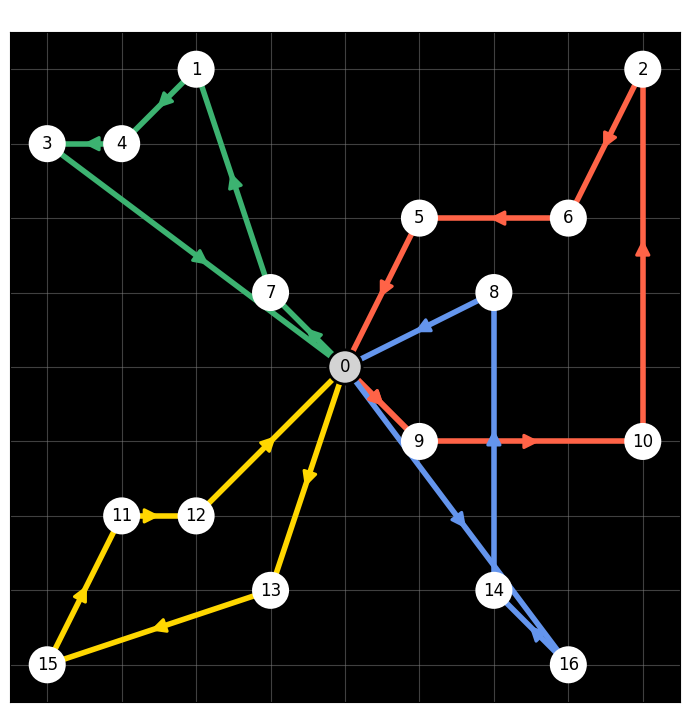

In [ ]:
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.animation import FuncAnimation

def create_data_model():
    """Stores the data for the problem."""
    data = {} # 딕셔너리
    data["distance_matrix"] = [
        # fmt: off
      [0, 548, 776, 696, 582, 274, 502, 194, 308, 194, 536, 502, 388, 354, 468, 776, 662],
      [548, 0, 684, 308, 194, 502, 730, 354, 696, 742, 1084, 594, 480, 674, 1016, 868, 1210],
      [776, 684, 0, 992, 878, 502, 274, 810, 468, 742, 400, 1278, 1164, 1130, 788, 1552, 754],
      [696, 308, 992, 0, 114, 650, 878, 502, 844, 890, 1232, 514, 628, 822, 1164, 560, 1358],
      [582, 194, 878, 114, 0, 536, 764, 388, 730, 776, 1118, 400, 514, 708, 1050, 674, 1244],
      [274, 502, 502, 650, 536, 0, 228, 308, 194, 240, 582, 776, 662, 628, 514, 1050, 708],
      [502, 730, 274, 878, 764, 228, 0, 536, 194, 468, 354, 1004, 890, 856, 514, 1278, 480],
      [194, 354, 810, 502, 388, 308, 536, 0, 342, 388, 730, 468, 354, 320, 662, 742, 856],
      [308, 696, 468, 844, 730, 194, 194, 342, 0, 274, 388, 810, 696, 662, 320, 1084, 514],
      [194, 742, 742, 890, 776, 240, 468, 388, 274, 0, 342, 536, 422, 388, 274, 810, 468],
      [536, 1084, 400, 1232, 1118, 582, 354, 730, 388, 342, 0, 878, 764, 730, 388, 1152, 354],
      [502, 594, 1278, 514, 400, 776, 1004, 468, 810, 536, 878, 0, 114, 308, 650, 274, 844],
      [388, 480, 1164, 628, 514, 662, 890, 354, 696, 422, 764, 114, 0, 194, 536, 388, 730],
      [354, 674, 1130, 822, 708, 628, 856, 320, 662, 388, 730, 308, 194, 0, 342, 422, 536],
      [468, 1016, 788, 1164, 1050, 514, 514, 662, 320, 274, 388, 650, 536, 342, 0, 764, 194],
      [776, 868, 1552, 560, 674, 1050, 1278, 742, 1084, 810, 1152, 274, 388, 422, 764, 0, 798],
      [662, 1210, 754, 1358, 1244, 708, 480, 856, 514, 468, 354, 844, 730, 536, 194, 798, 0],
        # fmt: on 
        # fmt는 formatting을 의미하는 것으로, 특정 프로그램이 해당 문구를 읽으면 자동적으로 본인들이 쉽게 가독성을 변경함
        # 대표적으로 Black, autoppep8 등의 프로그램들이 있다. 
        # 따라서, 해당 내용은 이 부분은 자동 정렬하지 말라는 뜻이다.
    ]
    data["num_vehicles"] = 4 # 차량 수
    data["depot"] = 0 # 모든 차량의 시작점. node의 시작점과도 같은 의미
    return data


def print_solution(data, manager, routing, solution):
    """Prints solution on console."""
    print(f"Objective: {solution.ObjectiveValue()}") #.ObjectiveValue(): 최적화된 결과값을 추출
    max_route_distance = 0
    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)
        plan_output = f"Route for vehicle {vehicle_id}:\n"
        route_distance = 0
        while not routing.IsEnd(index): # 해당 index가 끝나지 않는 경우, 아래의 과정을 계속 진행하라
            plan_output += f" {manager.IndexToNode(index)} -> " #IndexToNode() Index를 실제 Node로 변형함
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle( # () 내의 index를 전부 고려해 거리 cost를 계산
                previous_index, index, vehicle_id 
            )
        plan_output += f"{manager.IndexToNode(index)}\n"
        plan_output += f"Distance of the route: {route_distance}m\n"
        print(plan_output)
        max_route_distance = max(route_distance, max_route_distance)
    print(f"Maximum of the route distances: {max_route_distance}m")

    # 이때, 변수나 입력 값이 아예 없는데 어떻게 계산을 할 수 있는지 의아할 것이다. 해당 코딩들은 def 정의를 통해서 solution, callback(입력)에 대한 정의를 전부 따로따로 했기에 궁극적으로는 def의 내용을 모두 reading 하고 def solution이 작동.


def extract_routes(data, manager, routing, solution):
    """차량별 route를 [0, ..., 0] 형태로 추출"""
    routes = []

    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)
        route = [manager.IndexToNode(index)]

        while not routing.IsEnd(index):
            index = solution.Value(routing.NextVar(index))
            route.append(manager.IndexToNode(index))

        routes.append(route)

    return routes

def animate_routes(data, manager, routing, solution):
    routes = extract_routes(data, manager, routing, solution)
    print("routes =", routes)

    pos = {
        0: (0, 0),
        1: (-2, 4), 2: (4, 4), 3: (-4, 3), 4: (-3, 3),
        5: (1, 2), 6: (3, 2), 7: (-1, 1), 8: (2, 1),
        9: (1, -1), 10: (4, -1),
        11: (-3, -2), 12: (-2, -2), 13: (-1, -3),
        14: (2, -3), 15: (-4, -4), 16: (3, -4),
    }

    colors = ["tomato", "cornflowerblue", "mediumseagreen", "gold"]

    segments = []
    for vehicle_id, route in enumerate(routes):
        if len(route) <= 2 and route[0] == 0 and route[-1] == 0:
            continue

        for i in range(len(route) - 1):
            a = route[i]
            b = route[i + 1]
            segments.append((vehicle_id, a, b))

    print("segments =", segments)

    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("black")

    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-4.5, 4.5)
    ax.set_xticks(range(-4, 5))
    ax.set_yticks(range(-4, 5))
    ax.grid(True, color="gray", alpha=0.5, linewidth=0.8)
    ax.set_aspect("equal")
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # 노드 고정 표시
    for node, (x, y) in pos.items():
        if node == 0:
            face = "lightgray"
            edge = "black"
            txt = "black"
        else:
            face = "white"
            edge = "white"
            txt = "black"

        circle = Circle((x, y), 0.23, facecolor=face, edgecolor=edge, linewidth=2, zorder=5)
        ax.add_patch(circle)
        ax.text(x, y, str(node), ha="center", va="center", fontsize=12, color=txt, zorder=6)

    drawn_artists = []
    
    """해당 부분이 애니메이션화를 진행"""
    def update(frame):
        vehicle_id, a, b = segments[frame]
        color = colors[vehicle_id % len(colors)]

        x1, y1 = pos[a]
        x2, y2 = pos[b]

        line, = ax.plot(
            [x1, x2], [y1, y2],
            color=color, linewidth=4, solid_capstyle="round", zorder=2
        )

        arrow = ax.annotate(
            "",
            xy=(x1 * 0.45 + x2 * 0.55, y1 * 0.45 + y2 * 0.55),
            xytext=(x1 * 0.55 + x2 * 0.45, y1 * 0.55 + y2 * 0.45),
            arrowprops=dict(
                arrowstyle="-|>",
                color=color,
                lw=2.2,
                mutation_scale=22
            ),
            zorder=3
        )

        drawn_artists.append(line)
        drawn_artists.append(arrow)
        ax.set_title(f"Step {frame + 1}: vehicle {vehicle_id}, {a} -> {b}", color="white")
        return drawn_artists

    # 중요: 함수가 끝날 때까지 참조 유지
    anim = FuncAnimation(
        fig,
        update,
        frames=len(segments),
        interval=800,
        repeat=False,
        blit=False
    )

    plt.tight_layout()

    anim.save("C:/Users/c/Downloads/vrp_animation.gif", writer="pillow", fps=1)
    print("GIF 저장 완료: vrp_animation.gif")

    plt.show()

    return anim


def main():
    """Entry point of the program."""
    # Instantiate the data problem.
    data = create_data_model()

    # Create the routing index manager.
    manager = pywrapcp.RoutingIndexManager(
        len(data["distance_matrix"]), data["num_vehicles"], data["depot"]
    )

    # Create Routing Model.
    routing = pywrapcp.RoutingModel(manager)

    # Create and register a transit callback.
    def distance_callback(from_index, to_index):
        """Returns the distance between the two nodes."""
        # Convert from routing variable Index to distance matrix NodeIndex.
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return data["distance_matrix"][from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)

    # Define cost of each arc.
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Add Distance constraint.
    dimension_name = "Distance"
    routing.AddDimension(
        transit_callback_index,
        0,  # no slack
        3000,  # vehicle maximum travel distance
        True,  # start cumul to zero
        dimension_name,
    )
    distance_dimension = routing.GetDimensionOrDie(dimension_name)
    distance_dimension.SetGlobalSpanCostCoefficient(100)

    # Setting first solution heuristic.
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )

    # Solve the problem.
    solution = routing.SolveWithParameters(search_parameters)

    # Print solution on console.
    if solution:
        print_solution(data, manager, routing, solution)
        anim = animate_routes(data, manager, routing, solution)
        print(anim)
    else:
        print("No solution found !")


if __name__ == "__main__":
    main()

3. 실제 사례 적용

지난 번 과제 보고안 때, 선정한 지역들을 중심으로 위의 코드들을 해보자.(※ 추후에 clique 등의 알고리즘을 활용해 좀 더 효율적인 수요조사를 해볼 예정이다.)

지난 번에 과제에서 선정한 버티포트 후보군들에서 6개의 지역을 허브지역(장기 주차 + UAM 충전 등이 가능한 지역. 단, 주차 가능 대수는 배제하였음)으로 선정하고 나머지는 일반 버티포트로 선정.

현재는 연습용으로 수요, 소요 시간, 밀집도, UAM 이동 등의 조건은 전부 배제하고 '거리'만을 고려하였다.

Objective: 2952263
Route for vehicle 0:
 Bundang_Townhall ->  경기 성남시 분당구 야탑동 ->  경기 수원시 영통구 원천동 ->  경기 성남시 분당구 서현동 -> Bundang_Townhall
Distance of the route: 28733m

Route for vehicle 1:
 Gimpo_Airport ->  경기 부천시 중동 ->  인천 계양구 계산동 ->  경기 부천시 오정동 -> Gimpo_Airport
Distance of the route: 21133m

Route for vehicle 2:
 Beom_Gye ->  경기 안양시 만안구 안양동 ->  경기 안양시 동안구 평촌동 -> Beom_Gye
Distance of the route: 11639m

Route for vehicle 3:
 Kintex ->  서울 양천구 목동 ->  서울 강서구 등촌동 ->  서울 양천구 목동 ->  서울 강서구 화곡동 ->  서울 구로구 구로동 ->  서울 양천구 신정동 -> Kintex
Distance of the route: 17458m

Route for vehicle 4:
 Gwang_Myeong -> Gwang_Myeong
Distance of the route: 0m

Route for vehicle 5:
 Incheon_Airport -> Incheon_Airport
Distance of the route: 0m

Maximum of the route distances: 28733m
routes = [[14, 10, 4, 0, 14], [15, 12, 13, 3, 15], [16, 11, 5, 16], [17, 9, 8, 2, 1, 7, 6, 17], [18, 18], [19, 19]]
segments = [(0, 14, 10), (0, 10, 4), (0, 4, 0), (0, 0, 14), (1, 15, 12), (1, 12, 13), (1, 13, 3), (1, 3, 15), (2, 16, 1

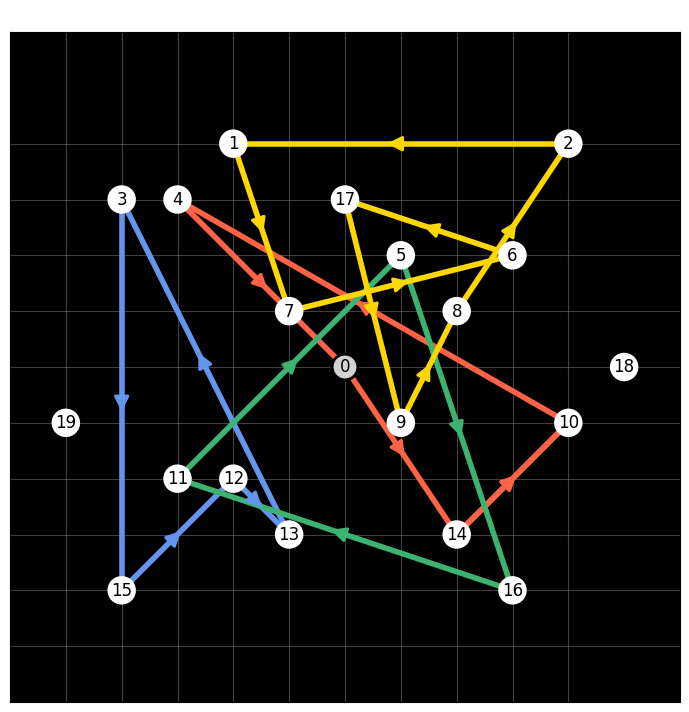

In [10]:
import os
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.animation import FuncAnimation
import pandas as pd
import geopandas as gpd
from haversine import haversine
from pathlib import Path
import numpy as np

def create_data_model():
    """Stores the data for the problem."""
    
    BASE_DIR = Path.cwd()
    vertiport = pd.read_csv(BASE_DIR / "dataset" /"버티포트_일반_후보지.csv", encoding="cp949")
    vertiport_hub = pd.read_csv(BASE_DIR / "dataset" /"핵심허브_경도_위도_명칭.csv", encoding="cp949")

    distance_vertiport =  pd.concat([vertiport, vertiport_hub], ignore_index=True)



    # id 기준 정렬
    distance_vertiport["id"] = range(len(distance_vertiport))

    ids = distance_vertiport["id"].values

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371000  # 지구 반지름 [m]

        lat1 = np.radians(lat1)
        lon1 = np.radians(lon1)
        lat2 = np.radians(lat2)
        lon2 = np.radians(lon2)

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
        c = 2 * np.arcsin(np.sqrt(a))

        return int(R * c)
    
    ids = distance_vertiport["id"].values
    lats = distance_vertiport["y_latitude"].values
    lons = distance_vertiport["x_longtitude"].values
    node_to_name = dict(zip(distance_vertiport["id"], distance_vertiport["NAME"]))

    n = len(distance_vertiport)

    distance_matrix = np.zeros((n, n), dtype=np.int64)

    for i in range(n):
        for j in range(n):
            distance_matrix[i, j] = haversine(
                lats[i], lons[i],
                lats[j], lons[j]
            )

    distance_df = pd.DataFrame(
        distance_matrix,
        index=ids,
        columns=ids
    )


    np.set_printoptions(suppress=True, precision=1)
    #print(distance_matrix)

    data = {} # 딕셔너리
    data["distance_matrix"] = distance_matrix.tolist()
    data["num_vehicles"] = 6 # 차량 수
    data["node_to_name"] = node_to_name
    data["starts"] = [14,15,16,17,18,19]
    data["ends"] = [14,15,16,17,18,19]
    return data


def print_solution(data, manager, routing, solution):
    """Prints solution on console."""
    print(f"Objective: {solution.ObjectiveValue()}") #.ObjectiveValue(): 최적화된 결과값을 추출
    max_route_distance = 0
    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)
        plan_output = f"Route for vehicle {vehicle_id}:\n"
        route_distance = 0
        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            name = data["node_to_name"][node]

            plan_output += f" {name} -> "

            previous_index = index
            index = solution.Value(routing.NextVar(index))

            route_distance += routing.GetArcCostForVehicle(
                previous_index, index, vehicle_id
            )

        # 마지막 노드
        end_node = manager.IndexToNode(index)
        end_name = data["node_to_name"][end_node]

        plan_output += f"{end_name}\n"
        plan_output += f"Distance of the route: {route_distance}m\n"

        print(plan_output)
        
        max_route_distance = max(route_distance, max_route_distance)
    print(f"Maximum of the route distances: {max_route_distance}m")

    # 이때, 변수나 입력 값이 아예 없는데 어떻게 계산을 할 수 있는지 의아할 것이다. 해당 코딩들은 def 정의를 통해서 solution, callback(입력)에 대한 정의를 전부 따로따로 했기에 궁극적으로는 def의 내용을 모두 reading 하고 def solution이 작동.


def extract_routes(data, manager, routing, solution):
    """차량별 route를 [0, ..., 0] 형태로 추출"""
    routes = []

    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)
        route = [manager.IndexToNode(index)]

        while not routing.IsEnd(index):
            index = solution.Value(routing.NextVar(index))
            route.append(manager.IndexToNode(index))

        routes.append(route)

    return routes

def animate_routes(data, manager, routing, solution):
    routes = extract_routes(data, manager, routing, solution)
    print("routes =", routes)

    pos = {
        0: (0, 0),

        1: (-2, 4), 2: (4, 4), 3: (-4, 3), 4: (-3, 3),
        5: (1, 2), 6: (3, 2), 7: (-1, 1), 8: (2, 1),

        9: (1, -1), 10: (4, -1),

        11: (-3, -2), 12: (-2, -2), 13: (-1, -3),
        14: (2, -3), 15: (-4, -4), 16: (3, -4),

        17: (0, 3),
        18: (5, 0),
        19: (-5, -1),

    }

    colors = ["tomato", "cornflowerblue", "mediumseagreen", "gold", "orchid", "turquoise"]

    segments = []
    for vehicle_id, route in enumerate(routes):
        if len(route) <= 2 and route[0] == 0 and route[-1] == 0:
            continue

        for i in range(len(route) - 1):
            a = route[i]
            b = route[i + 1]
            segments.append((vehicle_id, a, b))

    print("segments =", segments)

    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("black")

    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_xticks(range(-5, 5))
    ax.set_yticks(range(-5, 5))
    ax.grid(True, color="gray", alpha=0.5, linewidth=0.8)
    ax.set_aspect("equal")
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # 노드 고정 표시
    for node, (x, y) in pos.items():
        if node == 0:
            face = "lightgray"
            edge = "black"
            txt = "black"
        else:
            face = "white"
            edge = "white"
            txt = "black"

        circle = Circle((x, y), 0.23, facecolor=face, edgecolor=edge, linewidth=2, zorder=5)
        ax.add_patch(circle)
        ax.text(x, y, str(node), ha="center", va="center", fontsize=12, color=txt, zorder=6)

    drawn_artists = []

    def update(frame):
        vehicle_id, a, b = segments[frame]
        color = colors[vehicle_id % len(colors)]

        x1, y1 = pos[a]
        x2, y2 = pos[b]

        line, = ax.plot(
            [x1, x2], [y1, y2],
            color=color, linewidth=4, solid_capstyle="round", zorder=2
        )

        arrow = ax.annotate(
            "",
            xy=(x1 * 0.45 + x2 * 0.55, y1 * 0.45 + y2 * 0.55),
            xytext=(x1 * 0.55 + x2 * 0.45, y1 * 0.55 + y2 * 0.45),
            arrowprops=dict(
                arrowstyle="-|>",
                color=color,
                lw=2.2,
                mutation_scale=22
            ),
            zorder=3
        )

        drawn_artists.append(line)
        drawn_artists.append(arrow)
        ax.set_title(f"Step {frame + 1}: vehicle {vehicle_id}, {a} -> {b}", color="white")
        return drawn_artists

    # 중요: 함수가 끝날 때까지 참조 유지
    anim = FuncAnimation(
        fig,
        update,
        frames=len(segments),
        interval=800,
        repeat=False,
        blit=False
    )

    plt.tight_layout()

    anim.save("C:/Users/c/Downloads/vrp_animation.gif", writer="pillow", fps=1)
    print("GIF 저장 완료: vrp_animation.gif")

    plt.show()

    return anim


def main():
    """Entry point of the program."""
    # Instantiate the data problem.
    data = create_data_model()

    # Create the routing index manager.
    manager = pywrapcp.RoutingIndexManager(
        len(data["distance_matrix"]), data["num_vehicles"], data["starts"], data["ends"]
    )

    # Create Routing Model.
    routing = pywrapcp.RoutingModel(manager)

    # Create and register a transit callback.
    def distance_callback(from_index, to_index):
        """Returns the distance between the two nodes."""
        # Convert from routing variable Index to distance matrix NodeIndex.
        from_node = int(manager.IndexToNode(from_index))
        to_node = int(manager.IndexToNode(to_index))
        return int(data["distance_matrix"][from_node][to_node])

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)

    # Define cost of each arc.
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Add Distance constraint.
    dimension_name = "Distance"
    routing.AddDimension(
        transit_callback_index,
        0,  # no slack
        200000,  # vehicle maximum travel distance
        True,  # start cumul to zero
        dimension_name,
    )
    distance_dimension = routing.GetDimensionOrDie(dimension_name)
    distance_dimension.SetGlobalSpanCostCoefficient(100)

    # Setting first solution heuristic.
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )
    search_parameters.time_limit.seconds = 40

    # Solve the problem.
    solution = routing.SolveWithParameters(search_parameters)

    # Print solution on console.
    if solution:
        print_solution(data, manager, routing, solution)
        anim = animate_routes(data, manager, routing, solution)
        print(anim)
    else:
        print("No solution found !")


if __name__ == "__main__":
    main()

3-1. id와 node 매칭을 명확히 확인하기 위한 코드

In [4]:
import os
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.animation import FuncAnimation
import pandas as pd
import geopandas as gpd
from haversine import haversine
import numpy as np
from pathlib import Path

BASE_DIR = Path.cwd()
vertiport = pd.read_csv(BASE_DIR / "dataset" /"버티포트_일반_후보지.csv", encoding="cp949")
vertiport_hub = pd.read_csv(BASE_DIR / "dataset" /"핵심허브_경도_위도_명칭.csv", encoding="cp949")

distance_vertiport =  pd.concat([vertiport, vertiport_hub], ignore_index=True) # 2개의 csv를 통합


# id 기준 정렬
df = distance_vertiport.reset_index(drop=True)
df["id"] = range(len(df))

ids = df["id"].values
print(df["NAME"], df["id"])
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # 지구 반지름 [m]

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

lats = df["y_latitude"].values 
lons = df["x_longtitude"].values

n = len(df)

distance_matrix = np.zeros((n, n), dtype=np.int64)

for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = haversine(
            lats[i], lons[i],
            lats[j], lons[j]
        )

distance_df = pd.DataFrame(
    distance_matrix,
    index=ids,
    columns=ids
)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)



0       경기 성남시 분당구 서현동
1           서울 강서구 화곡동
2            서울 양천구 목동
3           경기 부천시 오정동
4       경기 수원시 영통구 원천동
5       경기 안양시 동안구 평촌동
6           서울 양천구 신정동
7           서울 구로구 구로동
8           서울 강서구 등촌동
9            서울 양천구 목동
10      경기 성남시 분당구 야탑동
11      경기 안양시 만안구 안양동
12           경기 부천시 중동
13          인천 계양구 계산동
14    Bundang_Townhall
15       Gimpo_Airport
16            Beom_Gye
17              Kintex
18        Gwang_Myeong
19     Incheon_Airport
Name: NAME, dtype: object 0      0
1      1
2      2
3      3
4      4
5      5
6      6
7      7
8      8
9      9
10    10
11    11
12    12
13    13
14    14
15    15
16    16
17    17
18    18
19    19
Name: id, dtype: int64


지금까지는 '거리'의 조건만을 고려해 프로그래밍을 하였다. BUT, 이번에는 조금 더 조건을 추가해 분석을 진행해보자.

1. 수요
-> 현재 위에서 지정한 HUB의 경우는 장기 주차, 정비, 충전 등이 가능한 곳으로 선정하였고 반영기준은 '거리'로만 활용하였기에 모든 vehicle을 사용하지 않았음을 알 수 있다.
따라서, 본 실험에서는 '거리' 외에 '수요'까지 반영해보고자 한다.

또한, 인천공항의 경우 주변 지역들과 멀리 떨어져 있고 왕복거리가 상당하므로 최소 비용을 중시하는 ortools의 VRP에서는 인천공항의 노선이 지속적으로 배제되고 있다.
하지만, 인천공항은 대한민국의 관문으로 매년 1억명에 가까운 사람들이 이곳을 방문하는 만큼 무수히 많은 수요가 있을 것으로 판단된다.
이를 위해서, 본 분석과정에서는 강제로 VRP 분석을 할 수 있도록 유도할 것이다.

How?
교수님꼐서 제공하신 중계기 'outgoing' data를 통해서 각 지역의 H3 지역의 code를 얻고 그 code를 통해 해당 지역의 시간대 별 수요를 분석해볼 예정이다.

2. 시간
-> UAM에서 가장 중요한 것들 중 하나는 '시간대'이다. 시간대 별로 수요가 다르기 때문이다.
또한, 여러 대의 UAM이 동시간 대에 Loss of separation이 발생할 수 있다.

비록, 본 코딩은 좌표평면으로 이동경로를 나타내므로 정확한 loss of separation을 확인 할 수는 없으나 같은 시간대에 경로 겹치는 event를 기록해볼 예정이다.

In [ ]:
import os
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.animation import FuncAnimation
import pandas as pd
import geopandas as gpd
from haversine import haversine
from pathlib import Path
import numpy as np

def create_data_model():
    """Stores the data for the problem."""
    
    BASE_DIR = Path.cwd()
    vertiport = pd.read_csv(BASE_DIR / "dataset" /"버티포트_일반_후보지.csv", encoding="cp949")
    vertiport_hub = pd.read_csv(BASE_DIR / "dataset" /"핵심허브_경도_위도_명칭.csv", encoding="cp949")

    distance_vertiport =  pd.concat([vertiport, vertiport_hub], ignore_index=True)



    # id 기준 정렬
    distance_vertiport["id"] = range(len(distance_vertiport))

    ids = distance_vertiport["id"].values

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371000  # 지구 반지름 [m]

        lat1 = np.radians(lat1)
        lon1 = np.radians(lon1)
        lat2 = np.radians(lat2)
        lon2 = np.radians(lon2)

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
        c = 2 * np.arcsin(np.sqrt(a))

        return int(R * c)
    
    ids = distance_vertiport["id"].values
    lats = distance_vertiport["y_latitude"].values
    lons = distance_vertiport["x_longtitude"].values
    node_to_name = dict(zip(distance_vertiport["id"], distance_vertiport["NAME"]))

    n = len(distance_vertiport)

    distance_matrix = np.zeros((n, n), dtype=np.int64)

    for i in range(n):
        for j in range(n):
            distance_matrix[i, j] = haversine(
                lats[i], lons[i],
                lats[j], lons[j]
            )

    distance_df = pd.DataFrame(
        distance_matrix,
        index=ids,
        columns=ids
    )


    np.set_printoptions(suppress=True, precision=1)
    #print(distance_matrix)

    data = {} # 딕셔너리
    data["distance_matrix"] = distance_matrix.tolist()
    data["num_vehicles"] = 6 # 차량 수
    data["node_to_name"] = node_to_name
    data["starts"] = [14,15,16,17,18,19]
    data["ends"] = [14,15,16,17,18,19]
    return data


def print_solution(data, manager, routing, solution):
    """Prints solution on console."""
    print(f"Objective: {solution.ObjectiveValue()}") #.ObjectiveValue(): 최적화된 결과값을 추출
    max_route_distance = 0
    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)
        plan_output = f"Route for vehicle {vehicle_id}:\n"
        route_distance = 0
        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            name = data["node_to_name"][node]

            plan_output += f" {name} -> "

            previous_index = index
            index = solution.Value(routing.NextVar(index))

            route_distance += routing.GetArcCostForVehicle(
                previous_index, index, vehicle_id
            )

        # 마지막 노드
        end_node = manager.IndexToNode(index)
        end_name = data["node_to_name"][end_node]

        plan_output += f"{end_name}\n"
        plan_output += f"Distance of the route: {route_distance}m\n"

        print(plan_output)
        
        max_route_distance = max(route_distance, max_route_distance)
    print(f"Maximum of the route distances: {max_route_distance}m")

    # 이때, 변수나 입력 값이 아예 없는데 어떻게 계산을 할 수 있는지 의아할 것이다. 해당 코딩들은 def 정의를 통해서 solution, callback(입력)에 대한 정의를 전부 따로따로 했기에 궁극적으로는 def의 내용을 모두 reading 하고 def solution이 작동.


def extract_routes(data, manager, routing, solution):
    """차량별 route를 [0, ..., 0] 형태로 추출"""
    routes = []

    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)
        route = [manager.IndexToNode(index)]

        while not routing.IsEnd(index):
            index = solution.Value(routing.NextVar(index))
            route.append(manager.IndexToNode(index))

        routes.append(route)

    return routes

def animate_routes(data, manager, routing, solution):
    routes = extract_routes(data, manager, routing, solution)
    print("routes =", routes)

    pos = {
        0: (0, 0),

        1: (-2, 4), 2: (4, 4), 3: (-4, 3), 4: (-3, 3),
        5: (1, 2), 6: (3, 2), 7: (-1, 1), 8: (2, 1),

        9: (1, -1), 10: (4, -1),

        11: (-3, -2), 12: (-2, -2), 13: (-1, -3),
        14: (2, -3), 15: (-4, -4), 16: (3, -4),

        17: (0, 3),
        18: (5, 0),
        19: (-5, -1),

    }

    colors = ["tomato", "cornflowerblue", "mediumseagreen", "gold", "orchid", "turquoise"]

    segments = []
    for vehicle_id, route in enumerate(routes):
        if len(route) <= 2 and route[0] == 0 and route[-1] == 0:
            continue

        for i in range(len(route) - 1):
            a = route[i]
            b = route[i + 1]
            segments.append((vehicle_id, a, b))

    print("segments =", segments)

    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("black")

    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_xticks(range(-5, 5))
    ax.set_yticks(range(-5, 5))
    ax.grid(True, color="gray", alpha=0.5, linewidth=0.8)
    ax.set_aspect("equal")
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # 노드 고정 표시
    for node, (x, y) in pos.items():
        if node == 0:
            face = "lightgray"
            edge = "black"
            txt = "black"
        else:
            face = "white"
            edge = "white"
            txt = "black"

        circle = Circle((x, y), 0.23, facecolor=face, edgecolor=edge, linewidth=2, zorder=5)
        ax.add_patch(circle)
        ax.text(x, y, str(node), ha="center", va="center", fontsize=12, color=txt, zorder=6)

    drawn_artists = []

    def update(frame):
        vehicle_id, a, b = segments[frame]
        color = colors[vehicle_id % len(colors)]

        x1, y1 = pos[a]
        x2, y2 = pos[b]

        line, = ax.plot(
            [x1, x2], [y1, y2],
            color=color, linewidth=4, solid_capstyle="round", zorder=2
        )

        arrow = ax.annotate(
            "",
            xy=(x1 * 0.45 + x2 * 0.55, y1 * 0.45 + y2 * 0.55),
            xytext=(x1 * 0.55 + x2 * 0.45, y1 * 0.55 + y2 * 0.45),
            arrowprops=dict(
                arrowstyle="-|>",
                color=color,
                lw=2.2,
                mutation_scale=22
            ),
            zorder=3
        )

        drawn_artists.append(line)
        drawn_artists.append(arrow)
        ax.set_title(f"Step {frame + 1}: vehicle {vehicle_id}, {a} -> {b}", color="white")
        return drawn_artists

    # 중요: 함수가 끝날 때까지 참조 유지
    anim = FuncAnimation(
        fig,
        update,
        frames=len(segments),
        interval=800,
        repeat=False,
        blit=False
    )

    plt.tight_layout()

    anim.save("C:/Users/c/Downloads/vrp_animation.gif", writer="pillow", fps=1)
    print("GIF 저장 완료: vrp_animation.gif")

    plt.show()

    return anim


def main():
    """Entry point of the program."""
    # Instantiate the data problem.
    data = create_data_model()

    # Create the routing index manager.
    manager = pywrapcp.RoutingIndexManager(
        len(data["distance_matrix"]), data["num_vehicles"], data["starts"], data["ends"]
    )

    # Create Routing Model.
    routing = pywrapcp.RoutingModel(manager)

    # Create and register a transit callback.
    def distance_callback(from_index, to_index):
        """Returns the distance between the two nodes."""
        # Convert from routing variable Index to distance matrix NodeIndex.
        from_node = int(manager.IndexToNode(from_index))
        to_node = int(manager.IndexToNode(to_index))
        return int(data["distance_matrix"][from_node][to_node])

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)

    # Define cost of each arc.
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Add Distance constraint.
    dimension_name = "Distance"
    routing.AddDimension(
        transit_callback_index,
        0,  # no slack
        200000,  # vehicle maximum travel distance
        True,  # start cumul to zero
        dimension_name,
    )
    distance_dimension = routing.GetDimensionOrDie(dimension_name)
    distance_dimension.SetGlobalSpanCostCoefficient(100)

    # Setting first solution heuristic.
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )
    search_parameters.time_limit.seconds = 40

    # Solve the problem.
    solution = routing.SolveWithParameters(search_parameters)

    # Print solution on console.
    if solution:
        print_solution(data, manager, routing, solution)
        anim = animate_routes(data, manager, routing, solution)
        print(anim)
    else:
        print("No solution found !")


if __name__ == "__main__":
    main()